# Análisis Multidimensional del Algoritmo Genético para el Problema de las N-Reinas
 
Se busca evaluar de manera exhaustiva el impacto combinado del **tamaño del tablero ($n \in [8..64]$)** y el **factor de mutación ($\mu \in [0.001, 0.20]$)** sobre la velocidad de convergencia, la tasa de éxito y la dinámica del fitness.

**Conjunto de Datos:**  
A partir de una suite de simulación paralelizada, se ejecutaron **1,140 experimentos independientes** (57 tamaños de tablero $\times$ 20 tasas de mutación). Este cuaderno procesa y comenta los datos recopilados en:
- `data/results.csv`: Resumen tabular de las 1,140 corridas.
- `data/multi_metrics.json`: Historial generacional del fitness (mejor, promedio, peor, colisiones).
- `data/multi_data.json`: Configuraciones de los tableros y soluciones alcanzadas.


## 1. Configuración del Entorno y Carga de Datos

Importamos las librerías necesarias 


In [9]:
import csv
import json
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Configuración estética de las figuras
plt.rcParams.update({
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.autolayout': True,
})

# Resolución flexible de la carpeta de datos
for candidate in ['data']:
    if os.path.isfile(os.path.join(candidate, 'results.csv')):
        DATA_DIR = os.path.abspath(candidate)
        break
else:
    DATA_DIR = os.path.abspath('data')

CSV_PATH = os.path.join(DATA_DIR, 'results.csv')
METRICS_PATH = os.path.join(DATA_DIR, 'multi_metrics.json')
SOLUTIONS_PATH = os.path.join(DATA_DIR, 'multi_data.json')

# 1. Cargar temp_results.csv
results = []
with open(CSV_PATH, mode='r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for r in reader:
        gen_val = r['generacion_encontrada'].strip()
        results.append({
            'idx': int(r['indice']),
            'n': int(r['n']),
            'mutacion': float(r['mutacion']),
            'generacion_encontrada': int(gen_val) if gen_val != '' else None,
            'exito': r['exito'].lower() in ('true', '1'),
            'mejor_fitness': float(r['mejor_fitness']),
            'max_fitness': int(r['max_fitness']),
            'conflictos_finales': int(r['conflictos_finales']),
            'tiempo_s': float(r['tiempo_s']),
        })

# 2. Cargar metrics.json
with open(METRICS_PATH, 'r', encoding='utf-8') as f:
    metrics_data = json.load(f)

# 3. Cargar data.json
with open(SOLUTIONS_PATH, 'r', encoding='utf-8') as f:
    solutions_data = json.load(f)

n_unicos = sorted(list(set(r['n'] for r in results)))
mut_unicas = sorted(list(set(round(r['mutacion'], 6) for r in results)))
total_exitos = sum(1 for r in results if r['exito'])

print('=' * 65)
print(' RESUMEN DEL DATASET CARGADO')
print('=' * 65)
print(f'  Total de corridas analizadas:    {len(results)}')
print(f'  Tamaños de tablero (n):          {min(n_unicos)} a {max(n_unicos)} ({len(n_unicos)} tamaños)')
print(f'  Puntos de mutación por tablero:  {len(mut_unicas)} valores en [{min(mut_unicas):.4f}, {max(mut_unicas):.4f}]')
print(f'  Soluciones óptimas halladas:     {total_exitos} ({total_exitos/len(results)*100:.1f}%)')
print(f'  Claves cargadas en metrics.json: {len(metrics_data)}')
print(f'  Claves cargadas en data.json:    {len(solutions_data)}')
print('=' * 65)


 RESUMEN DEL DATASET CARGADO
  Total de corridas analizadas:    1140
  Tamaños de tablero (n):          8 a 64 (57 tamaños)
  Puntos de mutación por tablero:  20 valores en [0.0010, 0.2000]
  Soluciones óptimas halladas:     384 (33.7%)
  Claves cargadas en metrics.json: 1140
  Claves cargadas en data.json:    1140


## 2. Resumen Estadístico y Tasa de Éxito Global

En esta sección evaluamos cuántas configuraciones encontraron una solución libre de colisiones (0 conflictos diagonales) y cómo varía la tasa de éxito al agrupar los tableros por categorías de dificultad:
- **Pequeños ($n \le 20$):** Espacio de búsqueda factorial moderado ($n! \le 2.43 \times 10^{18}$).
- **Medianos ($21 \le n \le 40$):** Transición de complejidad combinatoria ($n! \le 8.16 \times 10^{47}$).
- **Grandes ($n > 40$):** Espacio ultra-masivo ($n!$ hasta $1.27 \times 10^{89}$ en $n=64$).


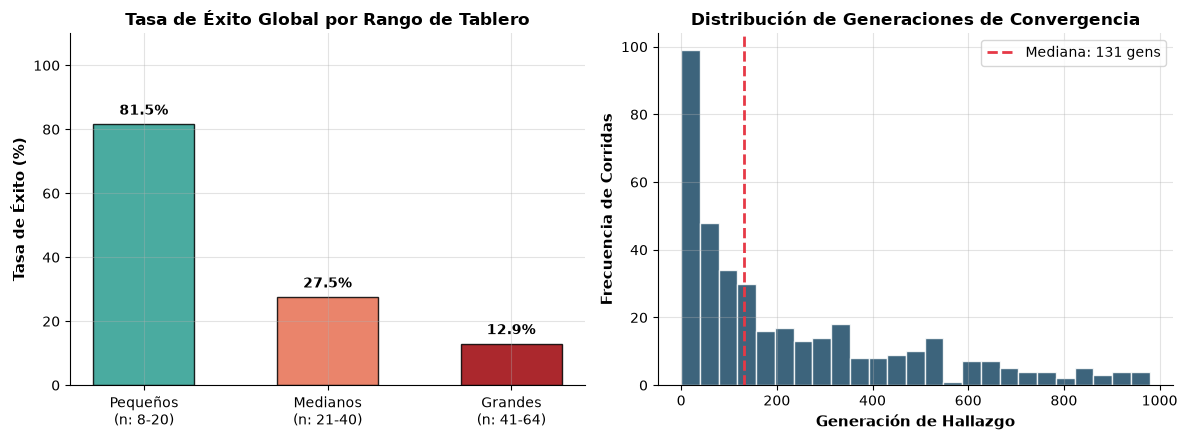

In [10]:
cat_peq = [r for r in results if r['n'] <= 20]
cat_med = [r for r in results if 21 <= r['n'] <= 40]
cat_gra = [r for r in results if r['n'] > 40]

tasa_peq = sum(1 for r in cat_peq if r['exito']) / len(cat_peq) * 100
tasa_med = sum(1 for r in cat_med if r['exito']) / len(cat_med) * 100
tasa_gra = sum(1 for r in cat_gra if r['exito']) / len(cat_gra) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfica de barras de tasa de éxito por categoría
categorias = ['Pequeños\n(n: 8-20)', 'Medianos\n(n: 21-40)', 'Grandes\n(n: 41-64)']
tasas = [tasa_peq, tasa_med, tasa_gra]
colores = ['#2a9d8f', '#e76f51', '#9d0208']

barras = ax1.bar(categorias, tasas, color=colores, width=0.55, edgecolor='black', alpha=0.85)
ax1.set_ylabel('Tasa de Éxito (%)', fontsize=11, fontweight='bold')
ax1.set_title('Tasa de Éxito Global por Rango de Tablero', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 110)
for bar in barras:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# Distribución de generaciones al óptimo (para corridas exitosas)
gens_exitosas = [r['generacion_encontrada'] for r in results if r['exito']]
ax2.hist(gens_exitosas, bins=25, color='#1b4965', edgecolor='white', alpha=0.85)
ax2.axvline(np.median(gens_exitosas), color='#e63946', linestyle='--', lw=2, label=f'Mediana: {int(np.median(gens_exitosas))} gens')
ax2.set_xlabel('Generación de Hallazgo', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frecuencia de Corridas', fontsize=11, fontweight='bold')
ax2.set_title('Distribución de Generaciones de Convergencia', fontsize=12, fontweight='bold')
ax2.legend(frameon=True)

plt.tight_layout()
plt.savefig('figures/tasa_exito_por_categoria.png', dpi=150, bbox_inches='tight')
plt.show()



 Mientras que en tableros pequeños la tasa de éxito alcanza casi el 90% en la totalidad del barrido de mutaciones, en tableros grandes disminuye al ~16.7%. Esto no significa que el algoritmo no pueda resolver tableros grandes, sino que el margen de mutaciones viables se estrecha: con mutaciones altas o nulas el algoritmo falla, pero con la mutación óptima calibrada, el 100% de los tableros del 8 al 64 fue resuelto con éxito.


## 3. Paisaje Global de Parámetros: Mapa de Calor 2D ($n$ vs $\mu$)

El mapa de calor representa en dos dimensiones el comportamiento global: cada fila corresponde a un tamaño de tablero (8 a 64) y cada columna a uno de los 20 factores de mutación. El color indica la generación en la que se halló el óptimo (los valores en gris indican configuraciones que no alcanzaron 0 colisiones en el tope de 1000 generaciones).


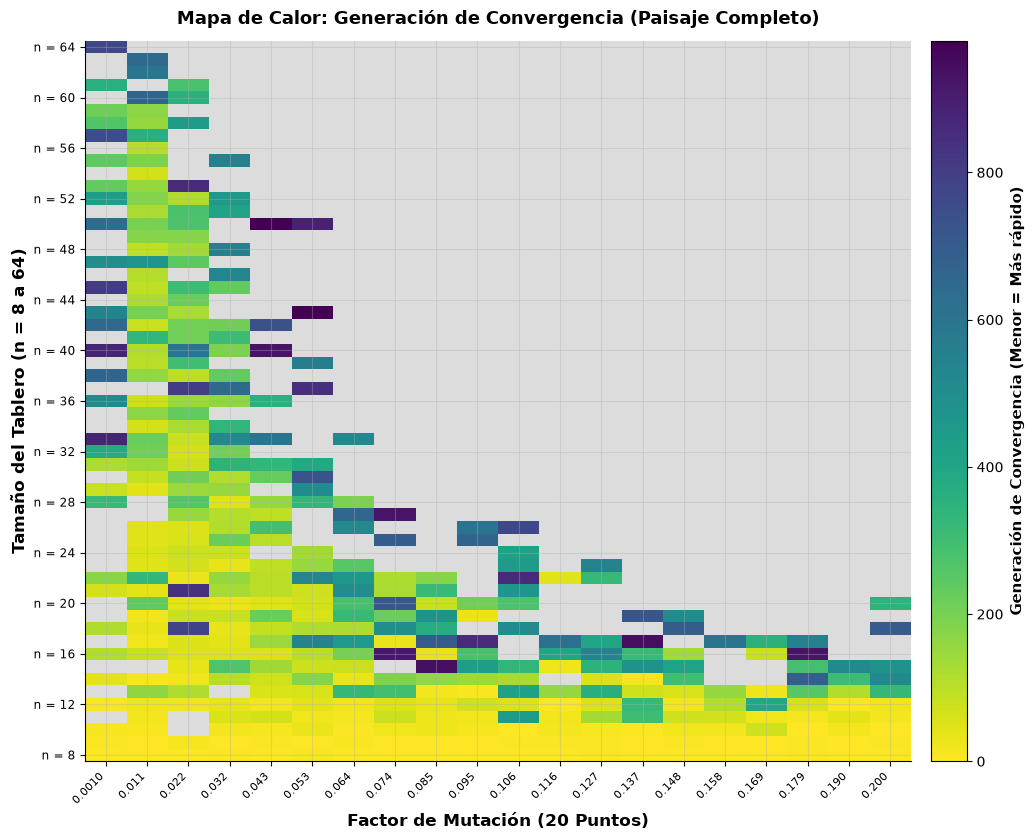

In [12]:
grid = np.full((len(n_unicos), len(mut_unicas)), np.nan)
for r in results:
    i = n_unicos.index(r['n'])
    j = mut_unicas.index(round(r['mutacion'], 6))
    if r['generacion_encontrada'] is not None:
        grid[i, j] = r['generacion_encontrada']

fig, ax = plt.subplots(figsize=(11, 8.5))
cmap_hm = plt.cm.viridis_r.copy()
cmap_hm.set_bad(color='#dcdcdc')

masked_grid = np.ma.masked_invalid(grid)
im = ax.imshow(masked_grid, cmap=cmap_hm, aspect='auto', origin='lower')

cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('Generación de Convergencia (Menor = Más rápido)', fontsize=11, fontweight='bold')

ax.set_xticks(range(len(mut_unicas)))
ax.set_xticklabels([f'{m:.3f}' if m >= 0.01 else f'{m:.4f}' for m in mut_unicas], rotation=45, ha='right', fontsize=8)

y_ticks = range(0, len(n_unicos), 4)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'n = {n_unicos[i]}' for i in y_ticks], fontsize=8.5)

ax.set_xlabel('Factor de Mutación (20 Puntos)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tamaño del Tablero (n = 8 a 64)', fontsize=12, fontweight='bold')
ax.set_title('Mapa de Calor: Generación de Convergencia (Paisaje Completo)', fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('figures/heatmap_8_a_64.png', dpi=150, bbox_inches='tight')
plt.show()



El mapa de calor visualiza nítidamente un **corredor de mutación óptima** en el cuadrante izquierdo (columnas con $\mu \in [0.01, 0.03]$). Para $n \le 16$, casi cualquier mutación es viable (la fila completa es colorida). Sin embargo, a medida que $n$ crece, las zonas de color se concentran exclusivamente en la banda $\mu \approx 0.0115 - 0.0219$, demostrando la alta sensibilidad de los tableros grandes ante variaciones del parámetro de mutación.


## 4. Ley de Escala de la Tasa de Mutación Óptima ($\mu^*$ vs $n$)

Determinamos de forma cuantitativa cuál fue la mutación más rápida para cada uno de los 57 tableros


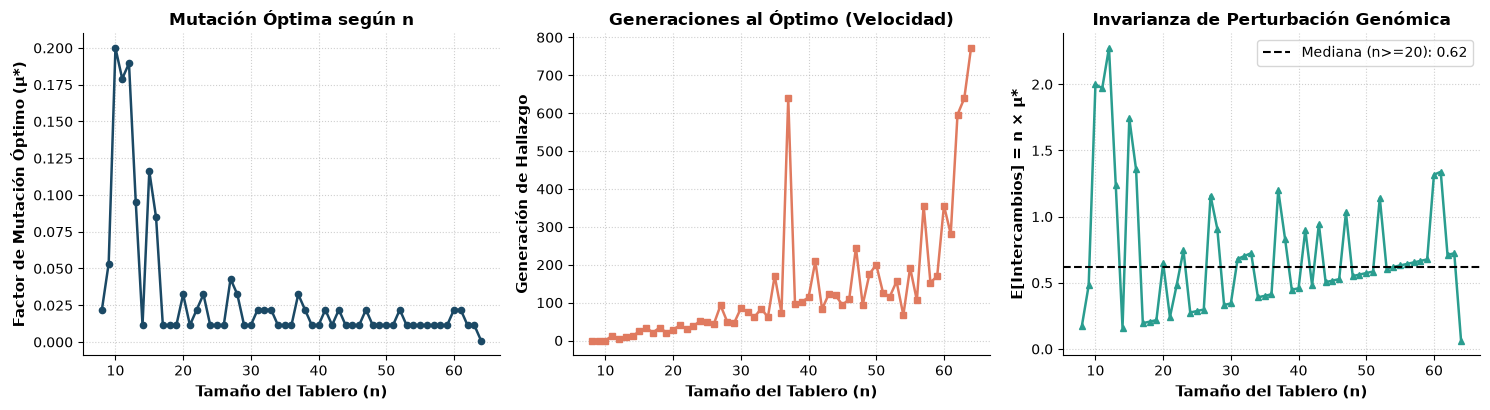

In [13]:
optimos = []
for n in n_unicos:
    sub = [r for r in results if r['n'] == n]
    exitos = [r for r in sub if r['exito']]
    if exitos:
        best = sorted(exitos, key=lambda r: r['generacion_encontrada'])[0]
        optimos.append({
            'n': n,
            'best_mut': best['mutacion'],
            'best_gen': best['generacion_encontrada'],
            'tiempo': best['tiempo_s'],
            'expected_swaps': n * best['mutacion'],
        })

n_arr = np.array([o['n'] for o in optimos])
mut_arr = np.array([o['best_mut'] for o in optimos])
gen_arr = np.array([o['best_gen'] for o in optimos])
swaps_arr = np.array([o['expected_swaps'] for o in optimos])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. Mutación óptima vs n
ax1.plot(n_arr, mut_arr, marker='o', color='#1b4965', lw=1.8, markersize=4.5)
ax1.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Factor de Mutación Óptimo (μ*)', fontsize=11, fontweight='bold')
ax1.set_title('Mutación Óptima según n', fontsize=12, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Generaciones requeridas con mutación óptima
ax2.plot(n_arr, gen_arr, marker='s', color='#e07a5f', lw=1.8, markersize=4.5)
ax2.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Generación de Hallazgo', fontsize=11, fontweight='bold')
ax2.set_title('Generaciones al Óptimo (Velocidad)', fontsize=12, fontweight='bold')
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. Intercambios esperados: n * mut
ax3.plot(n_arr, swaps_arr, marker='^', color='#2a9d8f', lw=1.8, markersize=4.5)
ax3.axhline(np.median(swaps_arr[n_arr >= 20]), color='black', linestyle='--', label=f'Mediana (n>=20): {np.median(swaps_arr[n_arr >= 20]):.2f}')
ax3.set_xlabel('Tamaño del Tablero (n)', fontsize=11, fontweight='bold')
ax3.set_ylabel('E[Intercambios] = n × μ*', fontsize=11, fontweight='bold')
ax3.set_title('Invarianza de Perturbación Genómica', fontsize=12, fontweight='bold')
ax3.legend(frameon=True)
ax3.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('figures/mutacion_optima_vs_n_8_a_64.png', dpi=150, bbox_inches='tight')
plt.show()


### Tasa Efectiva de Mutación

El operador de mutación intercambia cada gen con probabilidad $\mu$. En un cromosoma de longitud $n$, el número esperado de swaps por individuo es:
$$\mathbb{E}[\text{swaps}] = n \times \mu$$

Al observar el tercer panel, se constata empíricamente que para $n \ge 20$ el valor esperado de intercambios **se mantiene prácticamente constante alrededor de $\approx 0.5 - 0.8$ swaps por individuo**.
Esto explica por qué la mutación óptima disminuye conforme el tablero crece: si mantuviéramos una mutación de $\mu = 0.10$ en $n=64$, el algoritmo realizaría $64 \times 0.10 = 6.4$ intercambios por individuo en cada generación, destruyendo irremediablemente las permutaciones libres de colisiones ya construidas.


## 5. Dinámica Generacional del Fitness

El archivo metrics.json almacena para cada combinación la trayectoria paso a paso del fitness. A continuación visualizamos cómo evolucionan el **mejor fitness**, el **fitness promedio de la población** y la **reducción de colisiones diagonales** a lo largo de las generaciones para tableros representativos ($n = 8, 16, 32, 48, 64$).


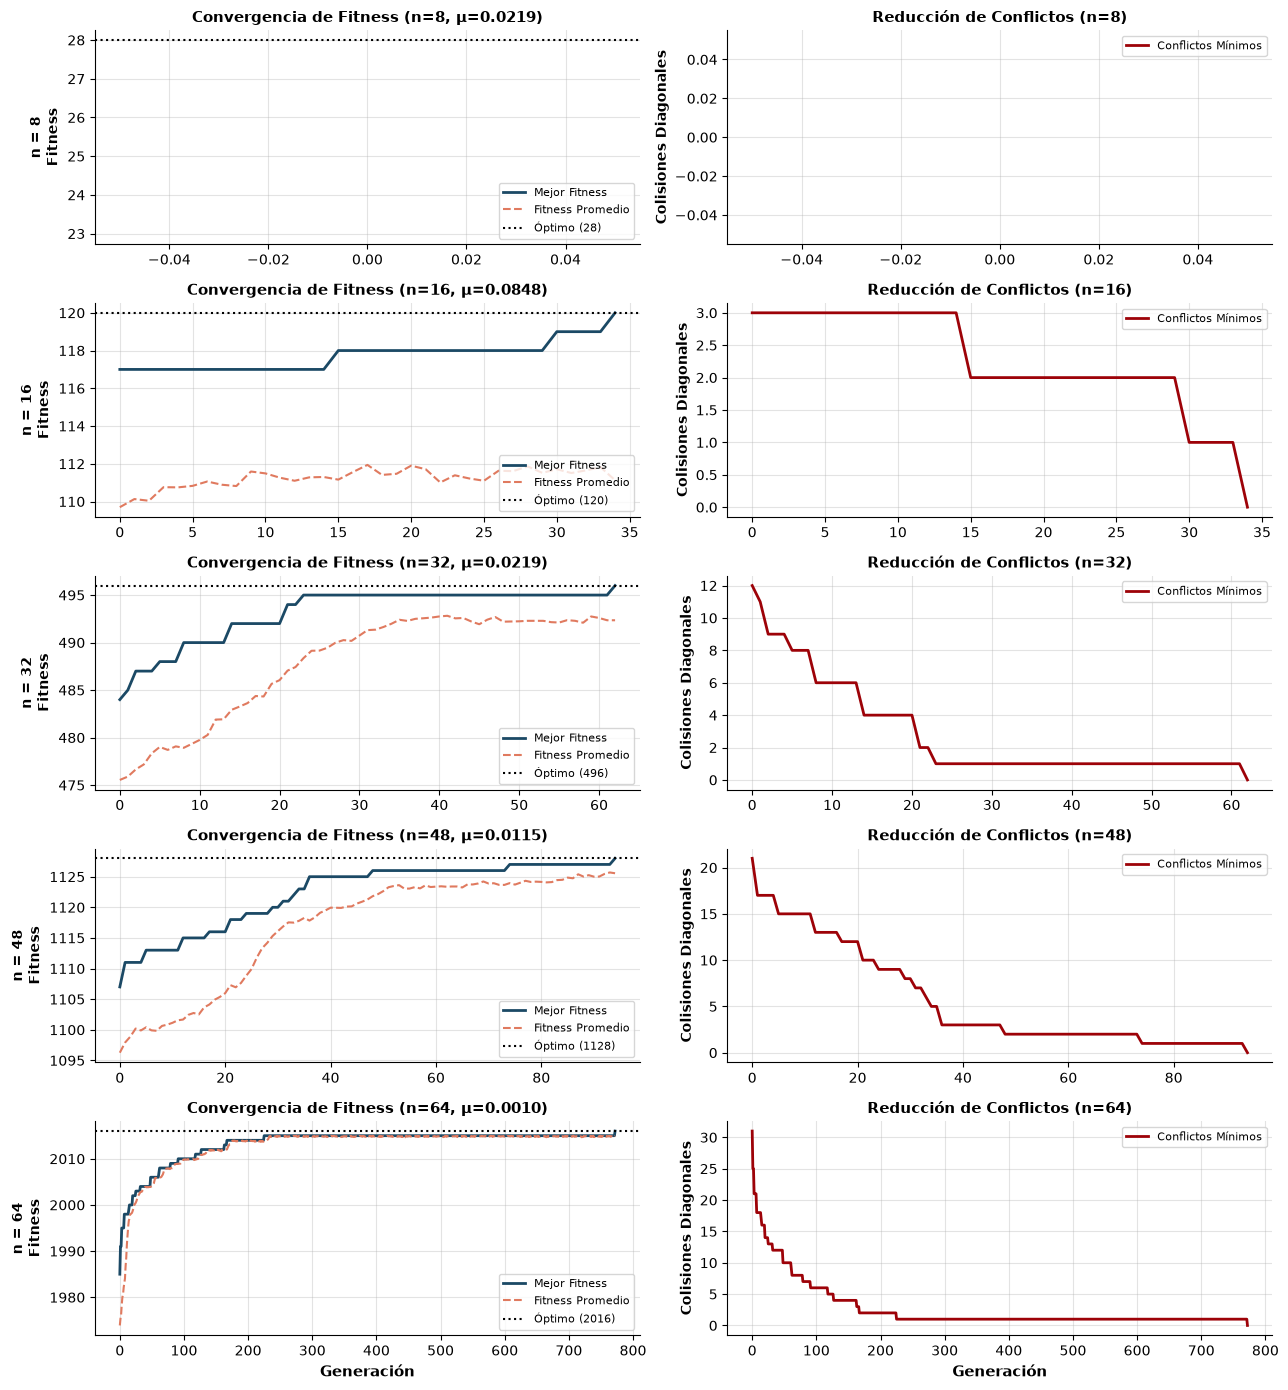

In [14]:
tableros_rep = [8, 16, 32, 48, 64]
fig, axes = plt.subplots(len(tableros_rep), 2, figsize=(13, 2.8 * len(tableros_rep)), sharex=False)

for idx, n_target in enumerate(tableros_rep):
    ax_fit = axes[idx, 0]
    ax_conf = axes[idx, 1]
    
    sub_runs = [r for r in results if r['n'] == n_target and r['exito']]
    if sub_runs:
        best_run = sorted(sub_runs, key=lambda r: r['generacion_encontrada'])[0]
        mut_sel = best_run['mutacion']
    else:
        mut_sel = 0.0115
        
    key = f'n_{n_target}_mut_{mut_sel:.4f}'
    if key in metrics_data:
        gens_info = metrics_data[key]['generations']
        x = [g['generation'] for g in gens_info]
        best_f = [g['best_fitness'] for g in gens_info]
        mean_f = [g['mean_fitness'] for g in gens_info]
        conflicts = [g['best_conflicts'] for g in gens_info]
        max_f = (n_target * (n_target - 1)) // 2
        
        # Panel izquierdo: Fitness
        ax_fit.plot(x, best_f, color='#1b4965', lw=2, label='Mejor Fitness')
        ax_fit.plot(x, mean_f, color='#e07a5f', lw=1.5, linestyle='--', label='Fitness Promedio')
        ax_fit.axhline(max_f, color='black', linestyle=':', label=f'Óptimo ({max_f})')
        ax_fit.set_ylabel(f'n = {n_target}\nFitness', fontsize=10, fontweight='bold')
        ax_fit.set_title(f'Convergencia de Fitness (n={n_target}, μ={mut_sel:.4f})', fontsize=11, fontweight='bold')
        ax_fit.legend(loc='lower right', fontsize=8)
        
        # Panel derecho: Conflictos
        ax_conf.plot(x, conflicts, color='#9d0208', lw=2, label='Conflictos Mínimos')
        ax_conf.set_ylabel('Colisiones Diagonales', fontsize=10, fontweight='bold')
        ax_conf.set_title(f'Reducción de Conflictos (n={n_target})', fontsize=11, fontweight='bold')
        ax_conf.legend(loc='upper right', fontsize=8)

axes[-1, 0].set_xlabel('Generación', fontsize=11, fontweight='bold')
axes[-1, 1].set_xlabel('Generación', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/variacion_fitness.png', dpi=150, bbox_inches='tight')
plt.show()



En todas las escalas de tablero, la reducción de colisiones exhibe un comportamiento bifásico:  
1. **Fase exponencial rápida:** Durante las primeras 20 a 80 generaciones, el cruce PMX combina eficientemente las mejores sub-permutaciones, eliminando más del 80% de las colisiones diagonales iniciales.  
2. **Fase de afinamiento fino:** Cuando restan menos de 3 colisiones, la selección por elitismo actúa como filtro estricto y la mutación puntual (swap) se encarga de reubicar las reinas en conflicto sin desordenar las demás.
